In [1]:
from pathlib import Path
import os, sys
import shutil
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Repo import path
# -----------------------
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

from fracture_utils.Ubem.brazilian_disk_bem import BrazilianDiskParams, ensure_bem_field
from fracture_utils.Ubem.disk_network_propagation import CrackGrowthParams, run_network_growth_uncoupled
from fracture_utils.Ubem.disk_crack_plotting import PlotParams, make_standard_plot_hook, plot_total_field
from fracture_utils.Ubem.coupling_blocks_v2 import BEMBlockV2, compose_solver_kwargs_v2
from fracture_utils.Ubem.disk_iterative_coupling import (
    compute_crack_boundary_tractions_direct,
    solve_bem_with_extra_boundary_tractions,
)
from fracture_utils.Ubem.boundary_conditions import build_boundary


# -----------------------
# Utility helpers
# -----------------------
def _l2norm2(tx, ty):
    tx = np.asarray(tx, float).reshape(-1)
    ty = np.asarray(ty, float).reshape(-1)
    return float(np.sqrt(np.dot(tx, tx) + np.dot(ty, ty)))


def _cycle_index_from_tag(tag: str):
    parts = str(tag).split("_")
    if len(parts) >= 2 and parts[0] == "cycle":
        try:
            return int(parts[1])
        except Exception:
            return None
    return None


def _vertex_degree_map(network):
    deg = {int(v.id): 0 for v in network.vertices}
    for e in network.edges:
        deg[int(e.v0)] = deg.get(int(e.v0), 0) + 1
        deg[int(e.v1)] = deg.get(int(e.v1), 0) + 1
    return deg


def _tip_points(network):
    deg = _vertex_degree_map(network)
    pts = []
    for v in network.vertices:
        if deg.get(int(v.id), 0) == 1:
            pts.append([float(v.x), float(v.y)])
    if not pts:
        return np.zeros((0, 2), float)
    return np.asarray(pts, float)


def _tip_edge_lengths(network):
    deg = _vertex_degree_map(network)
    edge_by_id = {int(e.id): e for e in network.edges}
    lengths = []

    for v in network.vertices:
        vid = int(v.id)
        if deg.get(vid, 0) != 1 or len(v.edges) == 0:
            continue

        e = edge_by_id.get(int(v.edges[0]))
        if e is None:
            continue

        other = int(e.v1) if int(e.v0) == vid else int(e.v0)
        vo = network.V(other)
        L = float(np.hypot(float(v.x) - float(vo.x), float(v.y) - float(vo.y)))
        if np.isfinite(L) and L > 0:
            lengths.append(L)

    return np.asarray(lengths, float)


def _min_tip_to_boundary_distance(res, boundary_mesh):
    net = getattr(getattr(res, "calc", None), "network", None)
    if net is None:
        return np.inf

    tips = _tip_points(net)
    if tips.shape[0] == 0:
        return np.inf

    bxy = np.column_stack([np.asarray(boundary_mesh.xm, float), np.asarray(boundary_mesh.ym, float)])
    d = tips[:, None, :] - bxy[None, :, :]
    return float(np.min(np.sqrt(np.sum(d * d, axis=2))))


def _characteristic_tip_length(res):
    net = getattr(getattr(res, "calc", None), "network", None)
    if net is None:
        return np.inf
    L = _tip_edge_lengths(net)
    if L.size == 0:
        return np.inf
    return float(np.median(L))


def _disk_external_boundary_tractions(mesh, disk_params):
    # External traction BC on the disk boundary (matching solve_bem_with_extra_boundary_tractions)
    theta_deg = np.asarray(mesh.theta_deg, dtype=float)
    L = np.asarray(mesh.length, dtype=float)

    arc_half = float(getattr(disk_params, "arc_half_angle_deg", 15.0))
    top = (theta_deg >= 90 - arc_half) & (theta_deg <= 90 + arc_half)
    bot = (theta_deg >= -90 - arc_half) & (theta_deg <= -90 + arc_half)

    L_top = float(np.sum(L[top]))
    L_bot = float(np.sum(L[bot]))
    if L_top <= 0 or L_bot <= 0:
        raise RuntimeError("Top/bottom loaded arc has zero length.")

    h = float(getattr(disk_params, "h", 1.0))
    pressure_top = float(disk_params.P_total) / (L_top * h)
    pressure_bot = float(disk_params.P_total) / (L_bot * h)

    tx = np.zeros(mesh.n_seg, float)
    ty = np.zeros(mesh.n_seg, float)

    # pressure_normal => traction = -p * n_out
    tx[top] += -pressure_top * np.asarray(mesh.nx, float)[top]
    ty[top] += -pressure_top * np.asarray(mesh.ny, float)[top]

    tx[bot] += -pressure_bot * np.asarray(mesh.nx, float)[bot]
    ty[bot] += -pressure_bot * np.asarray(mesh.ny, float)[bot]

    return tx, ty


def _copy_bem_arrays(src_dir: Path, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for fn in ("xs.npy", "ys.npy", "Sxx.npy", "Syy.npy", "Sxy.npy"):
        shutil.copy2(Path(src_dir) / fn, Path(dst_dir) / fn)


In [13]:
# -----------------------
# Output directory
# -----------------------
bem_dir = repo_root / "output" / "BEM_Brazilian_disk_2_direct"
bem_dir.mkdir(parents=True, exist_ok=True)

# -----------------------
# Network (YOU control)
# -----------------------
mm = 1e-3
vertices = np.array(
    [
        [0,  0.0 * mm, -4.0 * mm],
        [1,  0.0 * mm,  4.0 * mm],
    ],
    float,
)
connectivity = np.array([[0, 1]], int)

# -----------------------
# (1) BEM (fast reuse option)
# -----------------------
SKIP_BEM_SOLVE = True # set False to recompute

disk = BrazilianDiskParams(
    R=25.4e-3 / 2,
    P_total=3.8e3,
    E=231.52e9,
    nu=0.3,
    n_elem=30,
    n_grid=120,
    h=6.35e-3,
)

bem_block = BEMBlockV2(disk=disk, out_dir=bem_dir)
_bext = bem_block.ensure_external_only(
    recompute=(not SKIP_BEM_SOLVE),
    show=True,
    save_contours=True,
)
print(f"[bem-baseline] max|sxx| = {np.nanmax(np.abs(_bext.Sxx))*1e-6:.3f} MPa")

# Build boundary mesh ONCE (used for traction extraction each outer cycle)
boundary_mesh = build_boundary(
    {"type": "circle", "R": disk.R, "n_boundary": disk.n_elem, "center": (0.0, 0.0)}
)

# External traction BC norm (denominator for mismatch indicator)
tx_ext, ty_ext = _disk_external_boundary_tractions(boundary_mesh, disk)
ext_traction_norm = _l2norm2(tx_ext, ty_ext)


[bem-baseline] max|sxx| = 73.443 MPa


In [16]:
# -----------------------
# (2) Three coupling modes (simple names)
# -----------------------
# Modes requested:
#   1) no_coupling : external BEM field drives crack only
#   2) iterative   : reverse crack boundary traction into BEM, then re-solve crack
#   3) direct      : augmented KKT monolithic coupling

RUN_MODES = ("iterative",)
MAX_CYCLES_PER_CASE = 0   # 0 => initial state only, fastest comparison
SHOW_TOTAL_PLOTS = True

# Direct KKT controls
# Coupled correction form: baseline BEM load drives crack; KKT enforces boundary correction compatibility.
# Recommended stabilized direct setup: crack block is driven by baseline BEM applied field,
# while augmented constraints enforce boundary correction compatibility.
DIRECT_D_MODE = "correction_zero"
DIRECT_KEEP_BEM_APPLIED = True
DIRECT_RIDGE_Q = 1e-2
DIRECT_RIDGE_Y = 1e-6
DIRECT_C2_PROJECT_TAU = None

plot_params = PlotParams(
    cmap="jet",
    match_limits_to_crack=False,
    robust=True,
    robust_pct=97.0,
    symmetric=True,
    vmax_factor=2.0,
    n_levels=30,
    n_line_levels=30,
    dpi=300,
    fixed_vlim_mpa=30.0,
    augmented_correction_stride=6,
)


[solve] start: cycle_00_initial (Nv=2, Ne=1)
[solve] done : cycle_00_initial


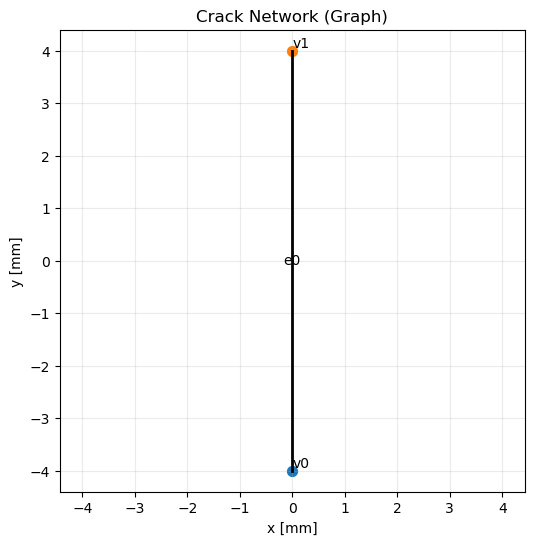

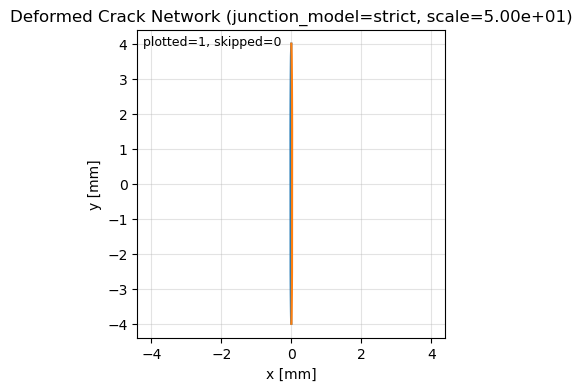

[iterative] ||t_cr||/||t_ext|| = 3.498e-02
[solve] start: cycle_00_initial (Nv=2, Ne=1)
[solve] done : cycle_00_initial


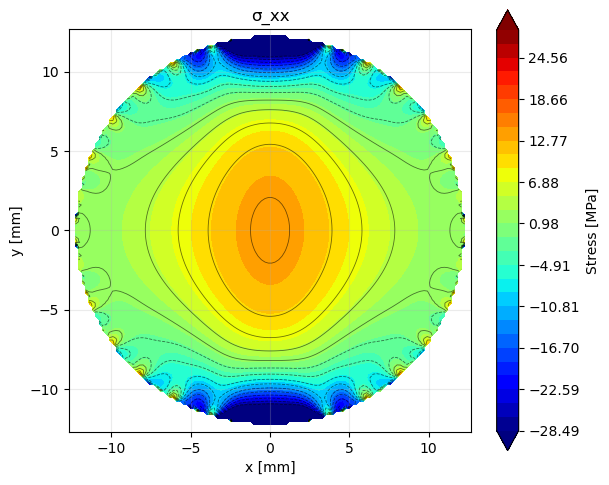

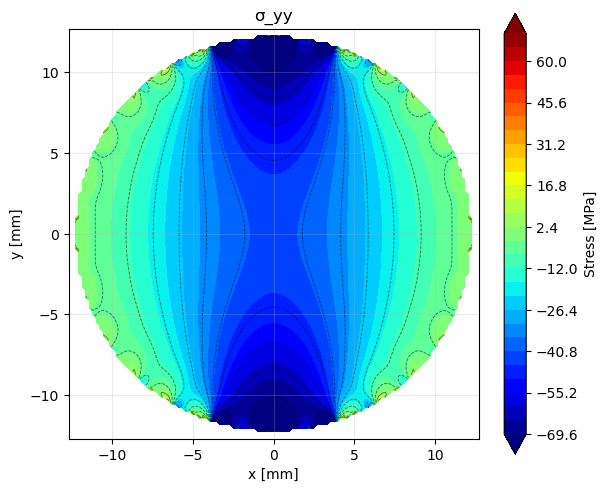

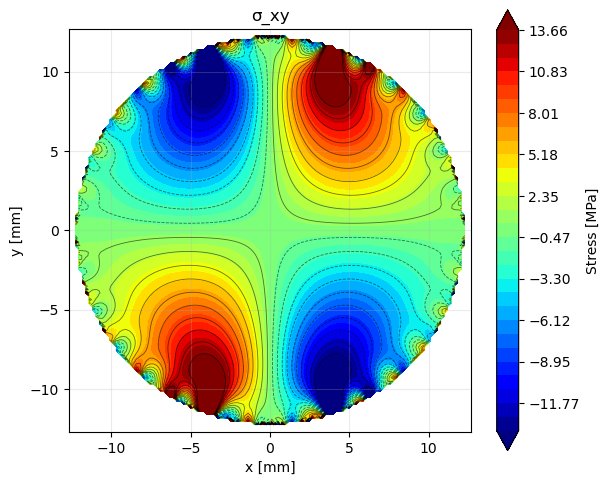

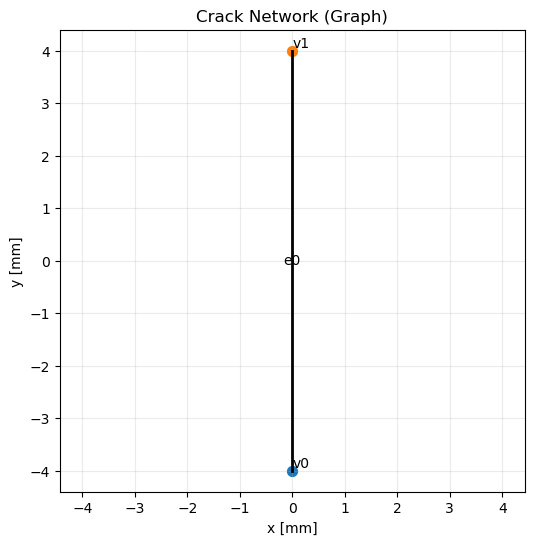

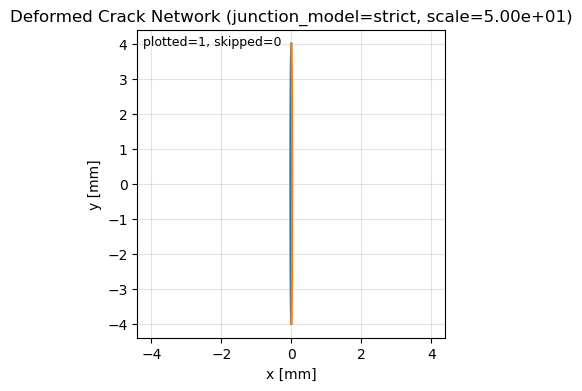

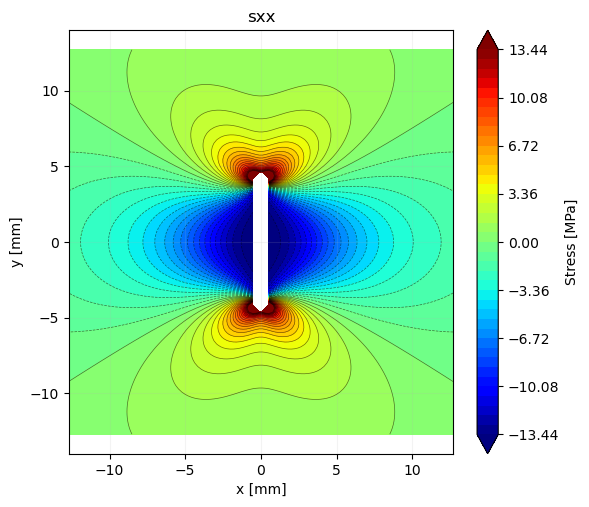

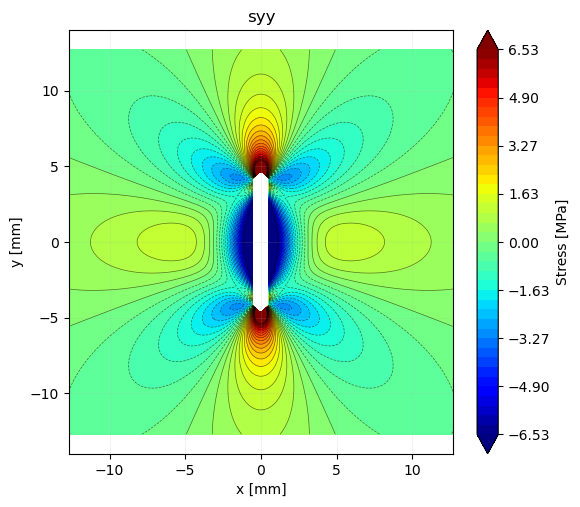

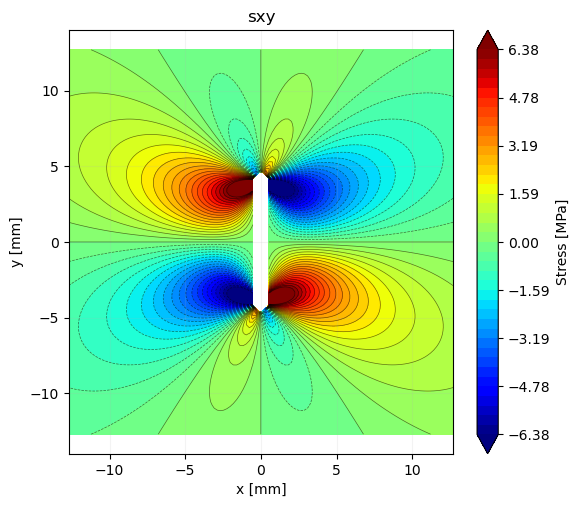

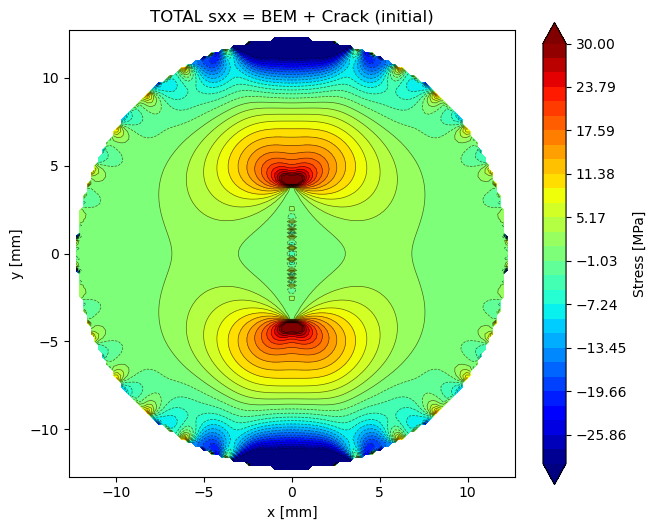

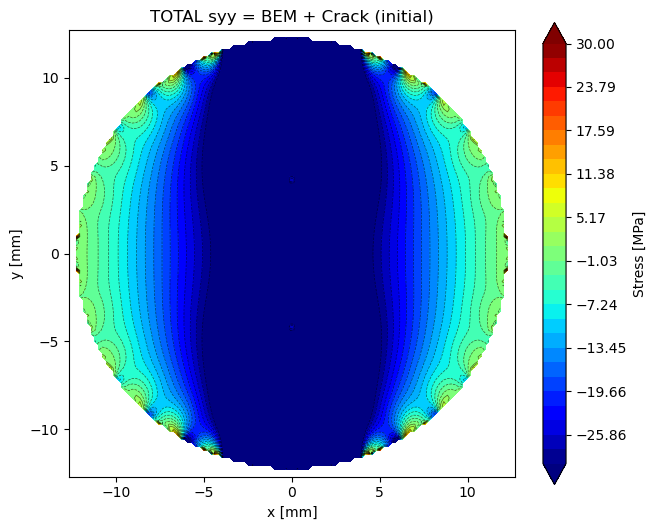

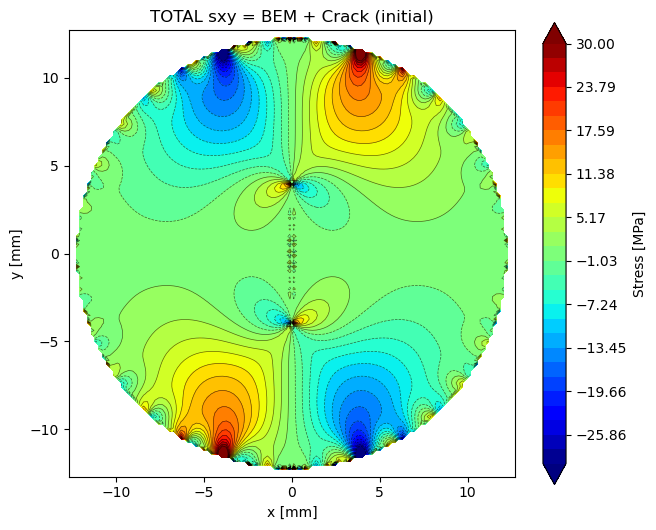

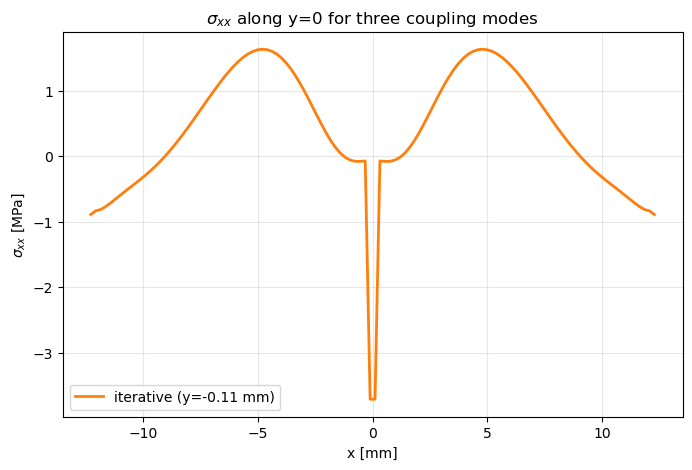

[done] saved line comparison: D:\Repos\Fracture\VCM_3_1\output\BEM_Brazilian_disk_2_direct\three_mode_compare\sigma_xx_line_y0_three_modes.png
[done] case outputs root: D:\Repos\Fracture\VCM_3_1\output\BEM_Brazilian_disk_2_direct\three_mode_compare

Sigma_xx along y=0 summary [MPa]
mode         y_used[mm]    min       max     peak_to_peak
iterative        -0.107    -3.709     1.630         5.339
[done] saved numeric summary: D:\Repos\Fracture\VCM_3_1\output\BEM_Brazilian_disk_2_direct\three_mode_compare\sigma_xx_line_y0_summary.csv


In [17]:
# -----------------------
# (3) Run the three cases + compare sigma_xx along y=0
# -----------------------
cases_root = bem_dir / "three_mode_compare"
cases_root.mkdir(parents=True, exist_ok=True)

# Keep a frozen baseline external-only BEM field
baseline_bem = cases_root / "baseline_external"
_copy_bem_arrays(bem_dir, baseline_bem)


def _run_case(case_name: str, case_bem_dir: Path, solver_kwargs: dict, run_tag: str = "run"):
    case_root = cases_root / case_name
    run_dir = case_root / run_tag
    run_dir.mkdir(parents=True, exist_ok=True)

    grow = CrackGrowthParams(
        max_cycles=int(MAX_CYCLES_PER_CASE),
        L_limit_mm=20.0,
        vertex_high=18,
        solver_kwargs=dict(solver_kwargs),
    )

    res = run_network_growth_uncoupled(
        bem_dir=case_bem_dir,
        out_dir=run_dir,
        vertices=vertices,
        connectivity=connectivity,
        params=grow,
        plot_hook=None,
    )
    return res


case_data = {}

# -----------------------
# Case 1: no_coupling
# -----------------------
if "no_coupling" in RUN_MODES:
    case_name = "no_coupling"
    case_root = cases_root / case_name
    case_bem = case_root / "bem"
    _copy_bem_arrays(baseline_bem, case_bem)

    solver_kwargs = compose_solver_kwargs_v2("one_way", base_solver_kwargs=None)
    res = _run_case(case_name, case_bem, solver_kwargs, run_tag="run")

    Sxx_tot, Syy_tot, Sxy_tot = plot_total_field(
        case_bem,
        res,
        out_dir=case_root / "plots",
        tag="initial",
        params=plot_params,
        show=SHOW_TOTAL_PLOTS,
    )
    case_data[case_name] = {
        "res": res,
        "bem_dir": case_bem,
        "xs": np.load(case_bem / "xs.npy"),
        "ys": np.load(case_bem / "ys.npy"),
        "Sxx_tot": Sxx_tot,
        "Syy_tot": Syy_tot,
        "Sxy_tot": Sxy_tot,
    }

# -----------------------
# Case 2: iterative
# -----------------------
if "iterative" in RUN_MODES:
    case_name = "iterative"
    case_root = cases_root / case_name
    case_bem = case_root / "bem"
    _copy_bem_arrays(baseline_bem, case_bem)

    solver_kwargs = compose_solver_kwargs_v2("one_way", base_solver_kwargs=None)

    # Predictor crack solve under external-only BEM
    res_pred = _run_case(case_name, case_bem, solver_kwargs, run_tag="predictor")

    # Crack-induced tractions on boundary, then reverse into BEM
    tx_cr, ty_cr = compute_crack_boundary_tractions_direct(
        res=res_pred,
        boundary_mesh=boundary_mesh,
    )
    print(f"[iterative] ||t_cr||/||t_ext|| = {_l2norm2(tx_cr, ty_cr)/max(ext_traction_norm,1e-30):.3e}")

    solve_bem_with_extra_boundary_tractions(
        disk_params=disk,
        bem_dir=case_bem,
        tx_extra=-tx_cr,
        ty_extra=-ty_cr,
        show=False,
    )

    # Corrected crack solve under updated BEM field
    res = _run_case(case_name, case_bem, solver_kwargs, run_tag="corrected")

    Sxx_tot, Syy_tot, Sxy_tot = plot_total_field(
        case_bem,
        res,
        out_dir=case_root / "plots",
        tag="initial",
        params=plot_params,
        show=SHOW_TOTAL_PLOTS,
    )
    case_data[case_name] = {
        "res": res,
        "bem_dir": case_bem,
        "xs": np.load(case_bem / "xs.npy"),
        "ys": np.load(case_bem / "ys.npy"),
        "Sxx_tot": Sxx_tot,
        "Syy_tot": Syy_tot,
        "Sxy_tot": Sxy_tot,
    }

# -----------------------
# Case 3: direct (augmented KKT)
# -----------------------
if "direct" in RUN_MODES:
    case_name = "direct"
    case_root = cases_root / case_name
    case_bem = case_root / "bem"
    _copy_bem_arrays(baseline_bem, case_bem)

    aug_payload = bem_block.build_augmented_payload(
        d_mode=DIRECT_D_MODE,
        gauss_n=4,
    )
    solver_kwargs = compose_solver_kwargs_v2(
        "full_kkt",
        base_solver_kwargs={"augmented_equilibrate": True, "augmented_equilibrate_eps": 1e-14, "augmented_equilibrate_cols": False, "augmented_physical_scaling": True, "augmented_enforce_crack_equilibrium": True},
        augmented_payload=aug_payload,
        augmented_ridge_q=float(DIRECT_RIDGE_Q),
        augmented_ridge_y=float(DIRECT_RIDGE_Y),
        augmented_keep_bem_applied=bool(DIRECT_KEEP_BEM_APPLIED),
    )

    res = _run_case(case_name, case_bem, solver_kwargs, run_tag="run")

    Sxx_tot, Syy_tot, Sxy_tot = plot_total_field(
        case_bem,
        res,
        out_dir=case_root / "plots",
        tag="initial",
        params=plot_params,
        show=SHOW_TOTAL_PLOTS,
    )
    case_data[case_name] = {
        "res": res,
        "bem_dir": case_bem,
        "xs": np.load(case_bem / "xs.npy"),
        "ys": np.load(case_bem / "ys.npy"),
        "Sxx_tot": Sxx_tot,
        "Syy_tot": Syy_tot,
        "Sxy_tot": Sxy_tot,
    }


# -----------------------
# y=0 line comparison: sigma_xx for all three modes
# -----------------------
fig, ax = plt.subplots(figsize=(8.0, 5.0))
colors = {
    "no_coupling": "tab:blue",
    "iterative": "tab:orange",
    "direct": "tab:green",
}

for mode in RUN_MODES:
    if mode not in case_data:
        continue
    xs = np.asarray(case_data[mode]["xs"], float)
    ys = np.asarray(case_data[mode]["ys"], float)
    Sxx_tot = np.asarray(case_data[mode]["Sxx_tot"], float)

    iy0 = int(np.argmin(np.abs(ys - 0.0)))
    y_sel = float(ys[iy0])
    sline_mpa = Sxx_tot[iy0, :] * 1e-6

    ax.plot(xs * 1e3, sline_mpa, lw=2.0, color=colors.get(mode, None), label=f"{mode} (y={y_sel*1e3:.2f} mm)")

ax.set_xlabel("x [mm]")
ax.set_ylabel(r"$\sigma_{xx}$ [MPa]")
ax.set_title(r"$\sigma_{xx}$ along y=0 for three coupling modes")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

line_png = cases_root / "sigma_xx_line_y0_three_modes.png"
fig.savefig(line_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"[done] saved line comparison: {line_png}")
print(f"[done] case outputs root: {cases_root}")


# -----------------------
# Numeric table for y=0 sigma_xx comparison
# -----------------------
summary_rows = []
for mode in RUN_MODES:
    if mode not in case_data:
        continue
    xs = np.asarray(case_data[mode]["xs"], float)
    ys = np.asarray(case_data[mode]["ys"], float)
    Sxx_tot = np.asarray(case_data[mode]["Sxx_tot"], float)

    iy0 = int(np.argmin(np.abs(ys - 0.0)))
    y_sel_mm = float(ys[iy0] * 1e3)
    sline_mpa = np.asarray(Sxx_tot[iy0, :] * 1e-6, float)

    smin = float(np.nanmin(sline_mpa))
    smax = float(np.nanmax(sline_mpa))
    spp = float(smax - smin)
    summary_rows.append((mode, y_sel_mm, smin, smax, spp))

if summary_rows:
    print()
    print("Sigma_xx along y=0 summary [MPa]")
    print("mode         y_used[mm]    min       max     peak_to_peak")
    for mode, ymm, smin, smax, spp in summary_rows:
        print(f"{mode:<12} {ymm:>10.3f} {smin:>9.3f} {smax:>9.3f} {spp:>13.3f}")

    csv_path = cases_root / "sigma_xx_line_y0_summary.csv"
    with open(csv_path, "w", encoding="utf-8") as f:
        f.write("mode,y_used_mm,sxx_min_mpa,sxx_max_mpa,sxx_peak_to_peak_mpa\n")
        for mode, ymm, smin, smax, spp in summary_rows:
            f.write(f"{mode},{ymm:.6f},{smin:.6f},{smax:.6f},{spp:.6f}\n")
    print(f"[done] saved numeric summary: {csv_path}")


In [5]:
# -----------------------
# (4) Direct-mode scaling diagnostics (no patching)
# -----------------------
# Run this AFTER cell (3).
# It reports constraint/traction magnitudes to localize unit-scaling issues.

if "direct" not in case_data:
    raise RuntimeError("direct case is not available. Ensure RUN_MODES includes 'direct' and rerun cell (3).")

res_direct = case_data["direct"]["res"]
sol_d = getattr(res_direct, "sol", {})
cpl = sol_d.get("coupling", {}) if isinstance(sol_d, dict) else {}
if (not isinstance(cpl, dict)) or (not bool(cpl.get("augmented", False))):
    raise RuntimeError("No augmented coupling metadata found in direct result.")

y = np.asarray(cpl.get("y_bc", []), float).reshape(-1)
nbd = int(cpl.get("n_boundary", 0))
if nbd <= 0 or y.size != 4 * nbd:
    raise RuntimeError(f"Unexpected y_bc shape: len(y)={y.size}, n_boundary={nbd}")

# Rebuild augmented payload with same direct settings used in cell (3)
aug_diag = bem_block.build_augmented_payload(
    d_mode=DIRECT_D_MODE,
    gauss_n=4,
)
C_bem = np.asarray(aug_diag["C_bem"], float)
C_bc = np.asarray(aug_diag["C_bc"], float)
d = np.asarray(aug_diag["d"], float).reshape(-1)

# y traction block from augmented unknowns
# y = [u_bc(2N), t_bc(2N)]
t_y = y[2 * nbd :]

# Crack-induced boundary tractions from direct crack solution
tx_cr_d, ty_cr_d = compute_crack_boundary_tractions_direct(
    res=res_direct,
    boundary_mesh=boundary_mesh,
)
t_cr_d = np.empty((2 * nbd,), float)
t_cr_d[0::2] = np.asarray(tx_cr_d, float)
t_cr_d[1::2] = np.asarray(ty_cr_d, float)

# Residuals of augmented constraints
r_bem = C_bem @ y
r_eq = (C_bc @ y) + t_cr_d - d   # should be ~0 for exact traction compatibility

# External traction norm reference
tx_ext_ref, ty_ext_ref = _disk_external_boundary_tractions(boundary_mesh, disk)
t_ext = np.empty((2 * nbd,), float)
t_ext[0::2] = tx_ext_ref
t_ext[1::2] = ty_ext_ref


def _nrm(v):
    v = np.asarray(v, float).reshape(-1)
    return float(np.linalg.norm(v))

print("[direct diag] norms (Pa on traction vectors):")
print(f"  ||y||                 = {_nrm(y):.6e}")
print(f"  ||t_y||               = {_nrm(t_y):.6e}")
print(f"  ||t_cr(direct)||      = {_nrm(t_cr_d):.6e}")
print(f"  ||d||                 = {_nrm(d):.6e}")
print(f"  ||t_ext||             = {_nrm(t_ext):.6e}")
print(f"  ||C_bem y||           = {_nrm(r_bem):.6e}")
print(f"  ||C_bc y + t_cr - d|| = {_nrm(r_eq):.6e}")

if _nrm(d) > 0:
    print(f"  rel ||eq_res||/||d||  = {_nrm(r_eq)/_nrm(d):.6e}")
if _nrm(t_ext) > 0:
    print(f"  ||t_cr(direct)||/||t_ext|| = {_nrm(t_cr_d)/_nrm(t_ext):.6e}")

# Compare direct crack traction norm to no_coupling / iterative crack traction norms
for mode_ref in ("no_coupling", "iterative"):
    if mode_ref not in case_data:
        continue
    res_ref = case_data[mode_ref]["res"]
    tx_r, ty_r = compute_crack_boundary_tractions_direct(res=res_ref, boundary_mesh=boundary_mesh)
    t_r = np.empty((2 * nbd,), float)
    t_r[0::2] = tx_r
    t_r[1::2] = ty_r
    nr = _nrm(t_r)
    if nr > 0:
        print(f"  ||t_cr(direct)||/||t_cr({mode_ref})|| = {_nrm(t_cr_d)/nr:.6e}")

# y=0 sigma_xx factor checks vs expected signatures 1/h and 10/h
if "no_coupling" in case_data:
    ys_d = np.asarray(case_data["direct"]["ys"], float)
    iy0_d = int(np.argmin(np.abs(ys_d - 0.0)))
    sxx_d = np.asarray(case_data["direct"]["Sxx_tot"], float)[iy0_d, :] * 1e-6

    ys_n = np.asarray(case_data["no_coupling"]["ys"], float)
    iy0_n = int(np.argmin(np.abs(ys_n - 0.0)))
    sxx_n = np.asarray(case_data["no_coupling"]["Sxx_tot"], float)[iy0_n, :] * 1e-6

    amp_d = float(np.nanmax(sxx_d) - np.nanmin(sxx_d))
    amp_n = float(np.nanmax(sxx_n) - np.nanmin(sxx_n))
    if amp_n > 0:
        fac = amp_d / amp_n
        h = float(disk.h)
        sig_1h = 1.0 / h
        sig_10h = 10.0 / h
        print("[line y=0 factor]")
        print(f"  factor direct/no_coupling = {fac:.6e}")
        print(f"  1/h                       = {sig_1h:.6e}")
        print(f"  10/h                      = {sig_10h:.6e}")
        print(f"  factor / (1/h)            = {fac/sig_1h:.6e}")
        print(f"  factor / (10/h)           = {fac/sig_10h:.6e}")


[direct diag] norms (Pa on traction vectors):
  ||y||                 = 4.025623e+07
  ||t_y||               = 4.025623e+07
  ||t_cr(direct)||      = 4.308354e+07
  ||d||                 = 0.000000e+00
  ||t_ext||             = 4.025058e+08
  ||C_bem y||           = 1.533701e-06
  ||C_bc y + t_cr - d|| = 6.730011e+06
  ||t_cr(direct)||/||t_ext|| = 1.070383e-01


In [6]:
# -----------------------
# (5) Matrix-level diagnostics for direct mode (no solver changes)
# -----------------------
# Run AFTER cell (4). This rebuilds the direct linearized blocks and reports
# rank/conditioning-style metrics to identify block scaling issues.

import numpy as _np

from fracture_utils.Usolver.build_geometry import vertex_degrees
from fracture_utils.Usolver.build_dipolar_polyline import build_polylines_full
from fracture_utils.Usolver.build_polar_polyline import build_polylines_half_branches
from fracture_utils.Usolver.parametrization_preprocess import normalize_representation, convert_polylines_to_csplines
from fracture_utils.Usolver.build_discretize import (
    discretize_polylines,
    allocate_unknowns,
    assemble_operator,
    assemble_boundary_traction_operator,
    assemble_bem_boundary_to_crack_traction_operator,
)
from fracture_utils.Usolver.constraints import build_constraints_full, build_constraints_half

if "direct" not in case_data:
    raise RuntimeError("direct case is not available. Run cell (3) first.")

res_direct = case_data["direct"]["res"]
calc_d = res_direct.calc
network = calc_d.network
material = calc_d.material
applied = calc_d.applied

# Match run_network_growth_uncoupled defaults + direct-mode overrides
solver_kwargs_dbg = dict(
    ne_half=100,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
)

# Normalize representation settings
rep_in, dist_in, collocation_mode = normalize_representation(
    solver_kwargs_dbg["representation"],
    solver_kwargs_dbg["node_distribution"],
)
crack_mode = str(solver_kwargs_dbg["crack_mode"]).lower().strip()
junction_model = str(solver_kwargs_dbg.get("junction_model", "strict")).lower().strip()

# Build polyline structures
deg = vertex_degrees(network)
if crack_mode == "full":
    polylines, edge_to_polyline = build_polylines_full(network)
else:
    polylines, edge_to_polyline = build_polylines_half_branches(network, deg)

polylines = convert_polylines_to_csplines(
    network,
    polylines,
    crack_mode=crack_mode,
    parametrization=str(solver_kwargs_dbg["parametrization"]),
    branch_param=None,
)

poly_panels = discretize_polylines(
    network,
    polylines,
    ne_half=int(solver_kwargs_dbg["ne_half"]),
    node_distribution=dist_in,
    collocation_mode=collocation_mode,
    representation=rep_in,
    nq_stress=int(solver_kwargs_dbg["nq_stress"]),
    tip_min_nodes=6,
    endpoint_min_nodes=6,
    kink_side_nodes=2,
    refine_junction_endpoints=True,
    refine_kinks=True,
    tip_cluster="power",
    tip_cluster_power=2.0,
    other_min_panels=1,
)

offsets, junction_dof, branch_end_dof, nunk = allocate_unknowns(
    poly_panels,
    deg,
    crack_mode=crack_mode,
    junction_model=junction_model,
)

K, rhs = assemble_operator(
    material=material,
    applied=applied,
    poly_panels=poly_panels,
    offsets=offsets,
    nunk=int(nunk),
    nq_col=int(solver_kwargs_dbg["nq_col"]),
)

if crack_mode == "full":
    C = build_constraints_full(
        poly_panels=poly_panels,
        offsets=offsets,
        nunk=nunk,
        use_tip_singular=(rep_in == "singular"),
    )
else:
    C, _P = build_constraints_half(
        network=network,
        deg=deg,
        poly_panels=poly_panels,
        offsets=offsets,
        junction_dof=junction_dof,
        branch_end_dof=branch_end_dof,
        nunk=nunk,
        junction_model=junction_model,
        theta_min_flat=5.0 * _np.pi / 180.0,
        soft_eta=1.0,
    )

# Augmented direct payload and coupling block
aug_dbg = bem_block.build_augmented_payload(
    d_mode=DIRECT_D_MODE,
    gauss_n=4,
)
Xb = _np.asarray(aug_dbg["boundary_xy"], float)
Nb = _np.asarray(aug_dbg["boundary_n"], float)
C_bem = _np.asarray(aug_dbg["C_bem"], float)
C_bc = _np.asarray(aug_dbg["C_bc"], float)
d_bc = _np.asarray(aug_dbg["d"], float).reshape(-1)

M = assemble_boundary_traction_operator(
    material=material,
    poly_panels=poly_panels,
    offsets=offsets,
    nunk=int(nunk),
    boundary_xy=Xb,
    boundary_n=Nb,
)

Nbc = assemble_bem_boundary_to_crack_traction_operator(
    material=material,
    poly_panels=poly_panels,
    boundary_x1=_np.asarray(aug_dbg["boundary_x1"], float),
    boundary_y1=_np.asarray(aug_dbg["boundary_y1"], float),
    boundary_x2=_np.asarray(aug_dbg["boundary_x2"], float),
    boundary_y2=_np.asarray(aug_dbg["boundary_y2"], float),
    gauss_n=4,
)

ny = int(C_bem.shape[1])
n_total = int(nunk) + ny

Kz = _np.hstack([K, Nbc])
C0 = _np.hstack([C, _np.zeros((C.shape[0], ny), float)]) if C.size else _np.zeros((0, n_total), float)
C1 = _np.hstack([_np.zeros((C_bem.shape[0], int(nunk)), float), C_bem])
C2 = _np.hstack([M, C_bc])
c2_rank_proj = -1
if "DIRECT_C2_PROJECT_TAU" in globals() and DIRECT_C2_PROJECT_TAU is not None:
    tau = float(DIRECT_C2_PROJECT_TAU)
    if _np.isfinite(tau) and tau > 0.0:
        U_m, s_m, _Vt_m = _np.linalg.svd(M, full_matrices=False)
        if s_m.size > 0 and _np.isfinite(s_m[0]) and s_m[0] > 0.0:
            c2_rank_proj = int(_np.sum(s_m > tau * float(s_m[0])))
            if c2_rank_proj > 0:
                Pm = U_m[:, :c2_rank_proj].T
                C2 = Pm @ C2
print(f"[matrix diag] C2 projected rank used = {c2_rank_proj}")
C_all = _np.vstack([C0, C1, C2])


def _rank_and_cond(A, name, tol_rel=1e-12):
    A = _np.asarray(A, float)
    if A.size == 0:
        print(f"[{name}] empty")
        return
    s = _np.linalg.svd(A, compute_uv=False)
    smax = float(s[0]) if s.size else 0.0
    if s.size == 0 or (not _np.isfinite(smax)) or smax <= 0.0:
        print(f"[{name}] invalid singular spectrum")
        return
    tol = float(tol_rel) * smax
    rank = int(_np.sum(s > tol))
    spos = s[s > tol]
    smin_pos = float(spos[-1]) if spos.size else _np.nan
    cond_eff = float(smax / smin_pos) if (spos.size and smin_pos > 0) else _np.inf
    print(f"[{name}] shape={A.shape}, rank={rank}, smax={smax:.3e}, smin_pos={smin_pos:.3e}, cond_eff={cond_eff:.3e}")


def _nrm(A):
    return float(_np.linalg.norm(_np.asarray(A, float)))

print("[matrix diag] dimensions")
print(f"  nunk (crack unknowns)    = {int(nunk)}")
print(f"  ny   (BEM unknowns)      = {int(ny)}")
print(f"  n_total                  = {int(n_total)}")
print(f"  K shape                  = {K.shape}")
print(f"  M shape                  = {M.shape}")
print(f"  C shape                  = {C.shape}")
print(f"  C_bem shape              = {C_bem.shape}")
print(f"  C_bc shape               = {C_bc.shape}")
print(f"  C_all shape              = {C_all.shape}")

print("\n[matrix diag] operator norms")
print(f"  ||K||_F      = {_nrm(K):.6e}")
print(f"  ||M||_F      = {_nrm(M):.6e}")
print(f"  ||Nbc||_F    = {_nrm(Nbc):.6e}")
print(f"  ||C_bem||_F  = {_nrm(C_bem):.6e}")
print(f"  ||C_bc||_F   = {_nrm(C_bc):.6e}")
print(f"  ||d||_2      = {_nrm(d_bc):.6e}")

print("\n[matrix diag] rank / condition indicators")
_rank_and_cond(K, "K")
_rank_and_cond(M, "M")
_rank_and_cond(C, "C")
_rank_and_cond(C_bem, "C_bem")
_rank_and_cond(C_all, "C_all")
_rank_and_cond(_np.vstack([Kz, C_all]), "[Kz; C_all]")

# Optional: compare block scales against K (helps detect under/over-weighted constraints)
nK = _nrm(K)
print("\n[matrix diag] block scale ratios (vs ||K||_F)")
if nK > 0:
    print(f"  ||M||/||K||      = {_nrm(M)/nK:.6e}")
    print(f"  ||C_bem||/||K||  = {_nrm(C_bem)/nK:.6e}")
    print(f"  ||C_bc||/||K||   = {_nrm(C_bc)/nK:.6e}")
else:
    print("  ||K|| is zero or invalid")


[matrix diag] C2 projected rank used = -1
[matrix diag] dimensions
  nunk (crack unknowns)    = 800
  ny   (BEM unknowns)      = 480
  n_total                  = 1280
  K shape                  = (800, 800)
  M shape                  = (240, 800)
  C shape                  = (4, 800)
  C_bem shape              = (240, 480)
  C_bc shape               = (240, 480)
  C_all shape              = (484, 1280)

[matrix diag] operator norms
  ||K||_F      = 9.859973e+11
  ||M||_F      = 2.060797e+10
  ||Nbc||_F    = 4.245112e+13
  ||C_bem||_F  = 7.910326e+00
  ||C_bc||_F   = 1.549193e+01
  ||d||_2      = 0.000000e+00

[matrix diag] rank / condition indicators
[K] shape=(800, 800), rank=800, smax=1.248e+11, smin_pos=3.882e+06, cond_eff=3.215e+04
[M] shape=(240, 800), rank=58, smax=1.420e+10, smin_pos=1.466e-02, cond_eff=9.685e+11
[C] shape=(4, 800), rank=4, smax=6.817e-04, smin_pos=6.655e-04, cond_eff=1.024e+00
[C_bem] shape=(240, 480), rank=238, smax=7.161e-01, smin_pos=1.882e-03, cond_eff=3.80

In [7]:
# -----------------------
# (6) Observability diagnostics: q, K residual, and M-spectrum energy
# -----------------------
# Run AFTER cell (5).

import numpy as _np

if "direct" not in case_data:
    raise RuntimeError("Run cell (3) first to populate case_data.")

# Reuse matrices assembled in cell (5): K, rhs, M, nunk, offsets, poly_panels
needed = ["K", "rhs", "M", "nunk", "offsets", "poly_panels"]
for _nm in needed:
    if _nm not in globals():
        raise RuntimeError(f"Missing '{_nm}' from cell (5). Run cell (5) first.")


def _extract_q_from_res(res, nunk_local, offsets_local, poly_panels_local):
    """
    Reconstruct crack DOF vector q from polyline_solutions.
    For half/core extra jump DOFs are not explicitly needed for M (zero columns),
    so they are left as zero.
    """
    q = _np.zeros((int(nunk_local),), float)
    sol = getattr(res, "sol", {})
    plist = sol.get("polyline_solutions", []) if isinstance(sol, dict) else []

    for pid, pp in enumerate(poly_panels_local):
        if pid >= len(plist):
            continue
        psol = plist[pid]
        off = int(offsets_local[pid])
        Np = int(pp["Np"])

        bIh = _np.asarray(psol.get("bI_hat", []), float).reshape(-1)
        bIIh = _np.asarray(psol.get("bII_hat", []), float).reshape(-1)
        if bIh.size != Np or bIIh.size != Np:
            continue

        for k in range(Np):
            q[off + 2 * k + 0] = float(bIh[k])
            q[off + 2 * k + 1] = float(bIIh[k])

    return q


def _nrm(v):
    return float(_np.linalg.norm(_np.asarray(v, float).reshape(-1)))


# SVD of M for weak/strong mode decomposition
s = _np.linalg.svd(M, compute_uv=False)
if s.size == 0:
    raise RuntimeError("Empty singular spectrum for M.")

smax = float(s[0])
if (not _np.isfinite(smax)) or smax <= 0.0:
    raise RuntimeError("Invalid M singular spectrum.")

# Weak modes: sigma/smax <= tau
for tau in (1e-6, 1e-8, 1e-10):
    _rank = int(_np.sum(s > tau * smax))
    print(f"[M spectrum] tau={tau:.0e}: effective rank={_rank}/{M.shape[1]}")

U, S, Vt = _np.linalg.svd(M, full_matrices=False)
V = Vt.T


def _energy_split_in_M_basis(q, tau=1e-8):
    alpha = V.T @ q
    rel = S / max(S[0], 1e-300)
    weak = rel <= float(tau)
    strong = ~weak
    e_tot = float(_np.dot(alpha, alpha))
    e_w = float(_np.dot(alpha[weak], alpha[weak])) if _np.any(weak) else 0.0
    e_s = float(_np.dot(alpha[strong], alpha[strong])) if _np.any(strong) else 0.0
    fw = e_w / e_tot if e_tot > 0 else _np.nan
    fs = e_s / e_tot if e_tot > 0 else _np.nan
    return fw, fs


print("\n[observability diag]")
print("mode         ||q||         ||Kq-rhs||      ||Mq||        ||Mq||/||rhs||   E_weak(tau=1e-8)")

rhs_n = _nrm(rhs)
store = {}
for mode in ("no_coupling", "iterative", "direct"):
    if mode not in case_data:
        continue
    q = _extract_q_from_res(case_data[mode]["res"], nunk, offsets, poly_panels)

    rK = K @ q - rhs
    # If monolithic Nbc is available and direct coupling stores y_bc,
    # use crack-equilibrium residual Kq + Nbc y - rhs for direct mode.
    if ('Nbc' in globals()) and mode == 'direct':
        cpl = getattr(case_data[mode]['res'], 'sol', {}).get('coupling', {})
        ybc = _np.asarray(cpl.get('y_bc', []), float).reshape(-1) if isinstance(cpl, dict) else _np.zeros((0,), float)
        if ybc.size == Nbc.shape[1]:
            rK = K @ q + Nbc @ ybc - rhs
    Mq = M @ q

    n_q = _nrm(q)
    n_rK = _nrm(rK)
    n_Mq = _nrm(Mq)
    ratio = n_Mq / rhs_n if rhs_n > 0 else _np.nan
    fw, fs = _energy_split_in_M_basis(q, tau=1e-8)

    store[mode] = dict(q=q, n_q=n_q, n_rK=n_rK, n_Mq=n_Mq, ratio=ratio, fw=fw)
    print(f"{mode:<12} {n_q:>11.3e}  {n_rK:>11.3e}  {n_Mq:>11.3e}  {ratio:>14.3e}  {fw:>14.3e}")

print("\n[relative ratios vs no_coupling]")
if "no_coupling" in store:
    b = store["no_coupling"]
    for mode in ("iterative", "direct"):
        if mode not in store:
            continue
        r_q = store[mode]["n_q"] / max(b["n_q"], 1e-300)
        r_m = store[mode]["n_Mq"] / max(b["n_Mq"], 1e-300)
        r_rk = store[mode]["n_rK"] / max(b["n_rK"], 1e-300)
        print(f"{mode:<12} ||q|| ratio={r_q:.3e}, ||Mq|| ratio={r_m:.3e}, ||Kq-rhs|| ratio={r_rk:.3e}")


[M spectrum] tau=1e-06: effective rank=28/800
[M spectrum] tau=1e-08: effective rank=37/800
[M spectrum] tau=1e-10: effective rank=49/800

[observability diag]
mode         ||q||         ||Kq-rhs||      ||Mq||        ||Mq||/||rhs||   E_weak(tau=1e-8)
direct         5.554e-01    6.605e+06    4.308e+07       9.300e-02       9.610e-01

[relative ratios vs no_coupling]


In [8]:
# -----------------------
# (8) Finite-value diagnostics for K/rhs/M assembly
# -----------------------
# Run AFTER cell (5). This does not modify solver logic.

import numpy as _np

needed = ["K", "rhs", "M", "poly_panels"]
for _nm in needed:
    if _nm not in globals():
        raise RuntimeError(f"Missing '{_nm}'. Run cell (5) first.")


def _finite_report(name, A):
    A = _np.asarray(A)
    total = A.size
    n_nan = int(_np.isnan(A).sum())
    n_inf = int(_np.isinf(A).sum())
    n_bad = n_nan + n_inf
    print(f"[{name}] shape={A.shape}, total={total}, bad={n_bad}, nan={n_nan}, inf={n_inf}")
    return n_bad

print("[finite diag] overall")
bad_rhs = _finite_report("rhs", rhs)
bad_K = _finite_report("K", K)
bad_M = _finite_report("M", M)

# K/rhs row-level diagnostics (2*ncoll rows)
row_bad = _np.any(~_np.isfinite(K), axis=1) | (~_np.isfinite(rhs))
idx_bad = _np.where(row_bad)[0]
print(f"[finite diag] bad K/rhs rows: {idx_bad.size}")

if idx_bad.size > 0:
    # Build row -> (polyline id, local collocation id, component) mapping
    ncol_per_poly = [int(len(pp["x_col"])) for pp in poly_panels]
    ncol_tot = int(sum(ncol_per_poly))
    cum = _np.cumsum([0] + ncol_per_poly)

    def _row_info(r):
        comp = "tn" if r < ncol_tot else "ts"
        j = int(r if r < ncol_tot else r - ncol_tot)
        pid = int(_np.searchsorted(cum, j, side="right") - 1)
        ic = int(j - cum[pid]) if (0 <= pid < len(ncol_per_poly)) else -1
        return pid, ic, comp

    print("[finite diag] first bad rows (up to 20):")
    for r in idx_bad[:20]:
        pid, ic, comp = _row_info(int(r))
        rv = rhs[int(r)]
        print(f"  row={int(r):4d} comp={comp} pid={pid} ic={ic} rhs={rv}")

    # Count bad rows per polyline/component
    counts = {}
    for r in idx_bad:
        pid, ic, comp = _row_info(int(r))
        key = (pid, comp)
        counts[key] = counts.get(key, 0) + 1
    print("[finite diag] bad-row counts by (pid, comp):")
    for (pid, comp), c in sorted(counts.items(), key=lambda kv: (-kv[1], kv[0][0], kv[0][1])):
        print(f"  pid={pid:3d}, comp={comp}: {c}")

# M row/col diagnostics
M_bad_rows = _np.where(_np.any(~_np.isfinite(M), axis=1))[0]
M_bad_cols = _np.where(_np.any(~_np.isfinite(M), axis=0))[0]
print(f"[finite diag] M bad rows: {M_bad_rows.size}, M bad cols: {M_bad_cols.size}")
if M_bad_rows.size:
    print("  first bad M rows:", M_bad_rows[:20])
if M_bad_cols.size:
    print("  first bad M cols:", M_bad_cols[:20])

# If finite, print robust rhs norms
if bad_rhs == 0:
    print(f"[finite diag] ||rhs||_2 = {float(_np.linalg.norm(rhs)):.6e}")
    print(f"[finite diag] max|rhs| = {float(_np.nanmax(_np.abs(rhs))):.6e}")
else:
    rhs_f = _np.asarray(rhs, float)
    rhs_f = rhs_f[_np.isfinite(rhs_f)]
    if rhs_f.size:
        print(f"[finite diag] finite-part ||rhs||_2 = {float(_np.linalg.norm(rhs_f)):.6e}")
        print(f"[finite diag] finite-part max|rhs| = {float(_np.max(_np.abs(rhs_f))):.6e}")


[finite diag] overall
[rhs] shape=(800,), total=800, bad=0, nan=0, inf=0
[K] shape=(800, 800), total=640000, bad=0, nan=0, inf=0
[M] shape=(240, 800), total=192000, bad=0, nan=0, inf=0
[finite diag] bad K/rhs rows: 0
[finite diag] M bad rows: 0, M bad cols: 0
[finite diag] ||rhs||_2 = 4.632571e+08
[finite diag] max|rhs| = 2.797310e+07


[bem-only equivalence: KKT vs standalone]
  n_boundary          = 120
  ||C_bem y||         = 7.626665e-20
  ||C_bc y - d||      = 1.285319e-06
  rel L2 Sxx          = 7.862952e-09
  rel L2 Syy          = 1.471377e-09
  rel L2 Sxy          = 6.748395e-09
  max|Sxx_kkt(masked)| [MPa] = 73.442744
  max|Sxx_ref|         [MPa] = 73.442744


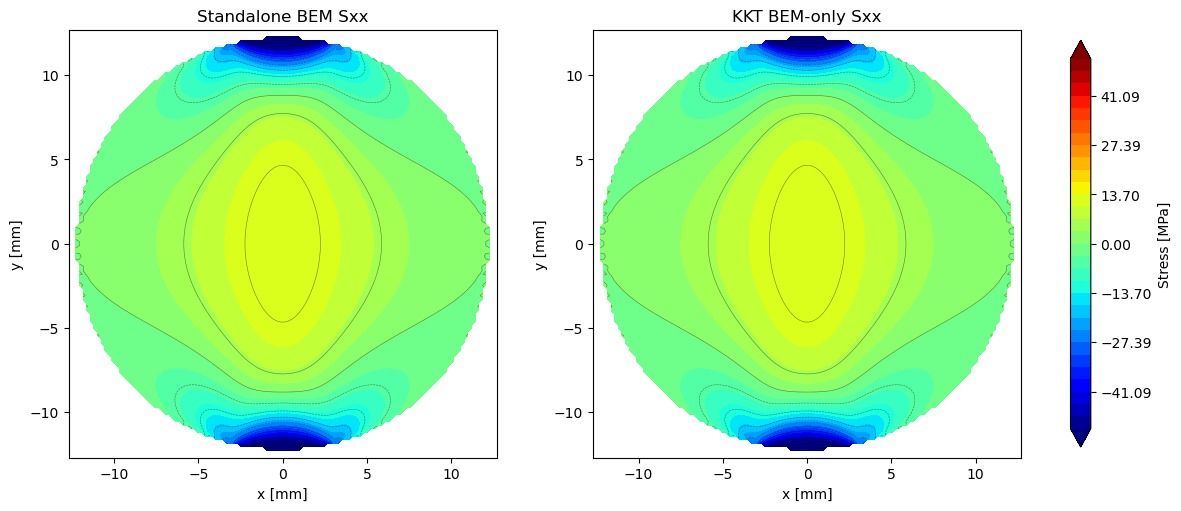

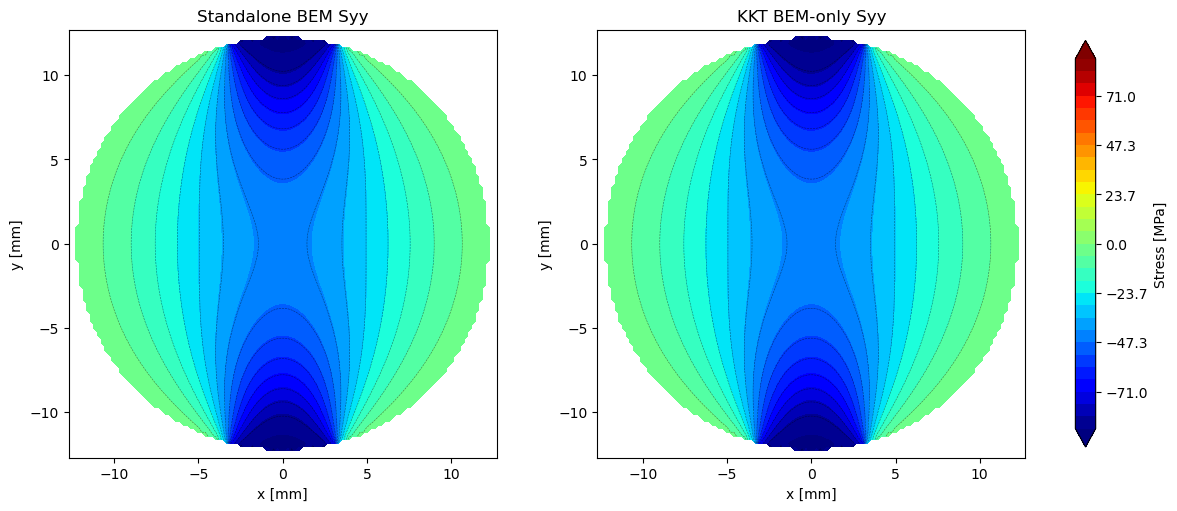

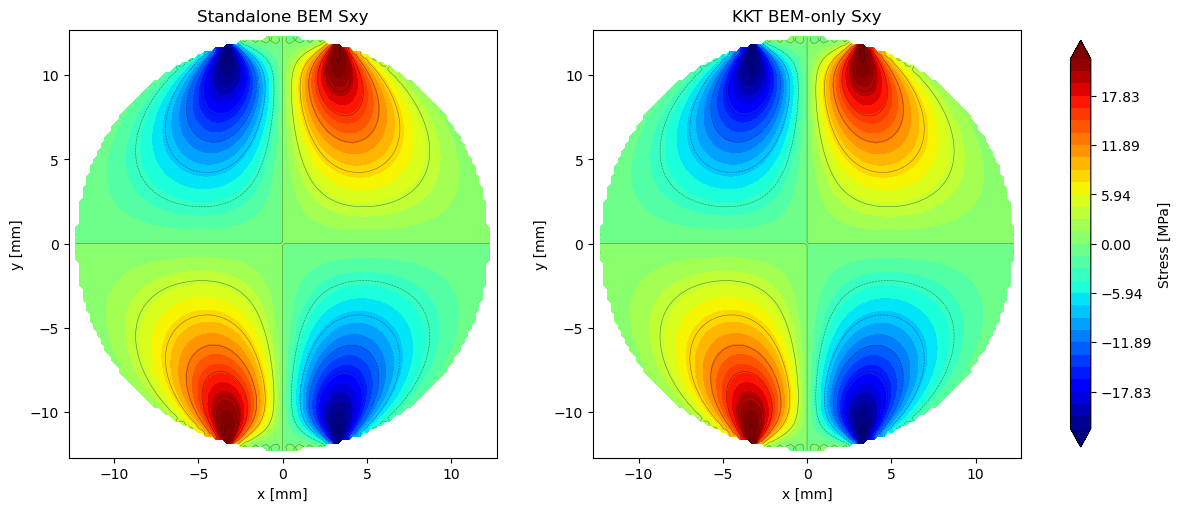

In [9]:
# -----------------------
# (9) BEM-only equivalence check: KKT block vs standalone BEM (q=0)
# -----------------------
# Purpose: verify KKT BEM block reproduces standalone BEM external-load field.

import numpy as _np
import matplotlib.pyplot as _plt

from fracture_utils.Usolver.KKT import solve_kkt_lsq_eq
from fracture_utils.Ubem.bem_solver import BEMSolver2D
from fracture_utils.Ubem.bem_stress_field import stress_on_grid

# Build augmented boundary data with full external traction target
aug_bem = bem_block.build_augmented_payload(d_mode="external_total", gauss_n=4)
C_bem = _np.asarray(aug_bem["C_bem"], float)
C_bc = _np.asarray(aug_bem["C_bc"], float)
d = _np.asarray(aug_bem["d"], float).reshape(-1)

x1 = _np.asarray(aug_bem["boundary_x1"], float).reshape(-1)
y1 = _np.asarray(aug_bem["boundary_y1"], float).reshape(-1)
x2 = _np.asarray(aug_bem["boundary_x2"], float).reshape(-1)
y2 = _np.asarray(aug_bem["boundary_y2"], float).reshape(-1)
nbd = int(x1.size)
ny = int(C_bem.shape[1])

# BEM-only constrained solve (q disabled):
#   C_bem y = 0
#   C_bc  y = d
K0 = _np.zeros((0, ny), float)
rhs0 = _np.zeros((0,), float)
Ceq = _np.vstack([C_bem, C_bc])
deq = _np.concatenate([_np.zeros((C_bem.shape[0],), float), d])

# Tiny ridge on y for numerical stability (min-norm selection)
rd = _np.full((ny,), 1e-14, float)
y = solve_kkt_lsq_eq(K=K0, rhs=rhs0, C=Ceq, d=deq, ridge=0.0, ridge_diag=rd)

u = y[:2*nbd]
t = y[2*nbd:]
ux = u[0::2]
uy = u[1::2]
tx = t[0::2]
ty = t[1::2]

# Reconstruct stress field from solved boundary unknowns
solver = BEMSolver2D(E=float(disk.E), nu=float(disk.nu), h=1.0, plane_strain=True)
for i in range(nbd):
    solver.add_element(float(x1[i]), float(y1[i]), float(x2[i]), float(y2[i]), True, 0.0, 0.0)
solver.u_x = _np.asarray(ux, float).copy()
solver.u_y = _np.asarray(uy, float).copy()
solver.t_x = _np.asarray(tx, float).copy()
solver.t_y = _np.asarray(ty, float).copy()

xs = _np.load(bem_dir / "xs.npy")
ys = _np.load(bem_dir / "ys.npy")
Sxx_ref = _np.load(bem_dir / "Sxx.npy")
Syy_ref = _np.load(bem_dir / "Syy.npy")
Sxy_ref = _np.load(bem_dir / "Sxy.npy")

Sxx_kkt, Syy_kkt, Sxy_kkt = stress_on_grid(solver, xs, ys, inside=None, fill=_np.nan)

mask = _np.isfinite(Sxx_ref) & _np.isfinite(Syy_ref) & _np.isfinite(Sxy_ref)
Sxx_kkt_m = _np.where(mask, Sxx_kkt, _np.nan)
Syy_kkt_m = _np.where(mask, Syy_kkt, _np.nan)
Sxy_kkt_m = _np.where(mask, Sxy_kkt, _np.nan)


def _rel_l2(A, B, m):
    a = _np.asarray(A, float)[m]
    b = _np.asarray(B, float)[m]
    n = float(_np.linalg.norm(a - b))
    dnm = float(_np.linalg.norm(b))
    return (n / dnm) if dnm > 0 else _np.nan

print("[bem-only equivalence: KKT vs standalone]")
print(f"  n_boundary          = {nbd}")
print(f"  ||C_bem y||         = {float(_np.linalg.norm(C_bem @ y)):.6e}")
print(f"  ||C_bc y - d||      = {float(_np.linalg.norm(C_bc @ y - d)):.6e}")
print(f"  rel L2 Sxx          = {_rel_l2(Sxx_kkt_m, Sxx_ref, mask):.6e}")
print(f"  rel L2 Syy          = {_rel_l2(Syy_kkt_m, Syy_ref, mask):.6e}")
print(f"  rel L2 Sxy          = {_rel_l2(Sxy_kkt_m, Sxy_ref, mask):.6e}")
print(f"  max|Sxx_kkt(masked)| [MPa] = {float(_np.nanmax(_np.abs(Sxx_kkt_m))*1e-6):.6f}")
print(f"  max|Sxx_ref|         [MPa] = {float(_np.nanmax(_np.abs(Sxx_ref))*1e-6):.6f}")

# Plot fields on the same disk mask as standalone BEM
Xg, Yg = _np.meshgrid(xs * 1e3, ys * 1e3, indexing="xy")


def _plot_component_pair(A_ref, A_kkt, name):
    A_ref_mpa = A_ref * 1e-6
    A_kkt_mpa = A_kkt * 1e-6
    v = _np.nanpercentile(_np.abs(A_ref_mpa[mask]), 99.0)
    if not _np.isfinite(v) or v <= 0:
        v = _np.nanmax(_np.abs(A_ref_mpa))
    levels = _np.linspace(-v, v, 31)

    fig, ax = _plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    cf0 = ax[0].contourf(Xg, Yg, A_ref_mpa, levels=levels, cmap="jet", extend="both")
    ax[0].contour(Xg, Yg, A_ref_mpa, levels=15, colors="k", linewidths=0.4, alpha=0.5)
    ax[0].set_title(f"Standalone BEM {name}")

    cf1 = ax[1].contourf(Xg, Yg, A_kkt_mpa, levels=levels, cmap="jet", extend="both")
    ax[1].contour(Xg, Yg, A_kkt_mpa, levels=15, colors="k", linewidths=0.4, alpha=0.5)
    ax[1].set_title(f"KKT BEM-only {name}")

    for a in ax:
        a.set_aspect("equal", "box")
        a.set_xlabel("x [mm]")
        a.set_ylabel("y [mm]")

    cbar = fig.colorbar(cf1, ax=ax.ravel().tolist(), shrink=0.95)
    cbar.set_label("Stress [MPa]")
    _plt.show()

_plot_component_pair(Sxx_ref, Sxx_kkt_m, "Sxx")
_plot_component_pair(Syy_ref, Syy_kkt_m, "Syy")
_plot_component_pair(Sxy_ref, Sxy_kkt_m, "Sxy")
